<a href="https://colab.research.google.com/github/Ameeghai/Quantum-RNG-Hybrid/blob/BSP-(NOISE-ANALYSIS)/noise_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.9 MB/s eta 0:00:00


In [ ]:
!pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.2 MB/s eta 0:00:00


In [ ]:
!pip install pylatexenc


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=994388cbb13be269bde50e26ebfcb40de082ff71dec898470cec24feb80ad330
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Example random number generated: 469317331
Shannon entropy: 12.2877 bits (max = 32)
Min-entropy: 12.2877 bits


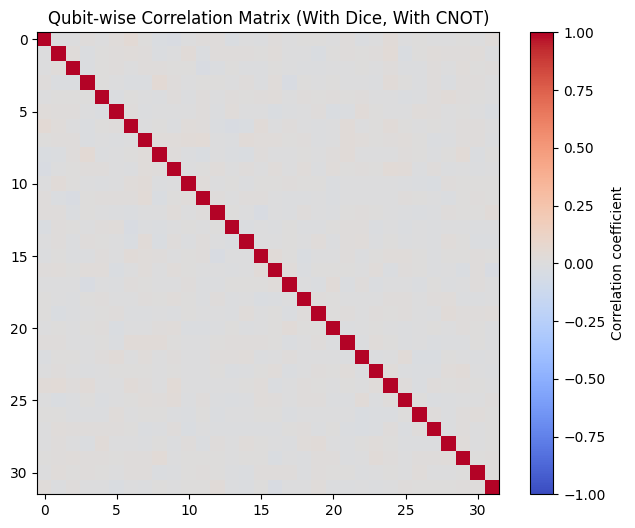

Average off-diagonal correlation = 0.0109

First 20 measurement sequences (shots):
[[1 1 1 0 1 1 0 1 1 0 1 0 1 1 1 1 0 0 1 1 1 0 0 1 0 0 1 1 0 0 0 1]
 [1 1 1 1 1 1 1 1 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 1 1 1 0 0 0 0]
 [1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 1 0 0 0 0 0]
 [0 1 1 1 1 1 1 0 0 1 0 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1 0 0 0 1 0 1]
 [0 1 1 1 1 1 1 1 1 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 0 1 1 0 0 1 1 1]
 [0 1 0 0 1 0 0 1 1 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 1 0 1 0]
 [0 0 1 0 1 1 1 1 0 0 0 0 0 1 1 0 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0]
 [1 0 1 1 0 1 1 0 1 1 0 1 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0]
 [0 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 1 1]
 [1 1 1 0 1 1 1 0 1 1 1 0 0 1 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 1]
 [0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0]
 [0 1 0 1 0 1 0 1 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 0]
 [1 0 0 0 1 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1]
 [1 0 0 0 0 1 0 1 1 0 1 1 0 0 1 1 0 0 1 0 0 0 

In [ ]:
# Hybrid QRNG: 32-bit, With Dice, With CNOT (5000 shots)
import numpy as np
from math import log2
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import random

# ----------------------------
# Step 1: Shot-Noise
def generate_shot_noise_bits(length=32):
    return np.random.choice([0, 1], size=length, p=[0.5, 0.5])

shot_noise_bits = generate_shot_noise_bits(32)

# ----------------------------
# Step 2: Quantum Circuit
qc = QuantumCircuit(32, 32)
for i, bit in enumerate(shot_noise_bits):
    if bit == 1:
        qc.x(i)

# ----------------------------
# Step 3: Hadamard
for q in range(32):
    qc.h(q)

# ----------------------------
# Step 4: Dice for Random CNOT Pairs
def dice_pairs(num_qubits=32):
    available = list(range(num_qubits))
    pairs = []
    while len(available) >= 2:
        d1, d2 = random.sample(available, 2)
        pairs.append((d1, d2))
        available.remove(d1)
        available.remove(d2)
    return pairs

pairs = dice_pairs(32)
for ctrl, tgt in pairs:
    qc.cx(ctrl, tgt)

# Dice measurement order
def dice_measurement_order(num_qubits=32):
    available = list(range(num_qubits))
    order = []
    while available:
        choice = random.choice(available)
        order.append(choice)
        available.remove(choice)
    return order

measurement_order = dice_measurement_order(32)
for idx, q in enumerate(measurement_order):
    qc.measure(q, idx)

# ----------------------------
# Step 5: Run Simulation
simulator = AerSimulator()
result = simulator.run(qc, shots=5000).result()
counts = result.get_counts()

# ----------------------------
# Step 6: Random Number, Entropy, Correlation
outcomes = list(counts.keys())
probabilities = np.array(list(counts.values())) / sum(list(counts.values()))
measured_bits = np.random.choice(outcomes, p=probabilities)
random_number = int(measured_bits, 2)
print(f"Example random number generated: {random_number}")

entropy = -np.sum([p*log2(p) for p in probabilities if p>0])
min_entropy = -log2(np.max(probabilities))
print(f"Shannon entropy: {entropy:.4f} bits (max = 32)")
print(f"Min-entropy: {min_entropy:.4f} bits")

bit_matrix = np.array([list(map(int, o)) for o in np.repeat(outcomes, list(counts.values()), axis=0)])
correlation_matrix = np.corrcoef(bit_matrix.T)
plt.figure(figsize=(8,6))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation coefficient')
plt.title("Qubit-wise Correlation Matrix (With Dice, With CNOT)")
plt.show()

num_qubits = correlation_matrix.shape[0]
avg_off_diag_corr = (np.sum(np.abs(correlation_matrix)) - num_qubits) / (num_qubits*(num_qubits-1))
print(f"Average off-diagonal correlation = {avg_off_diag_corr:.4f}")

print("\nFirst 20 measurement sequences (shots):")
print(bit_matrix[:20])
